In [10]:
import pandas as pd, numpy as np, json
np.random.seed(42)

S = pd.read_csv("outputs/team_strengths.csv", index_col=0)
meta = json.load(open("outputs/_glm_meta.json"))
INT, HOME, RHO = meta["intercept"], meta["home"], meta["rho"]
att, dfn = S["attack"].to_dict(), S["defend"].to_dict()

raw = pd.read_csv("https://raw.githubusercontent.com/martj42/international_results/master/results.csv")
fx = raw[(raw.tournament=="FIFA World Cup") & (raw.home_score.isna())][["home_team","away_team","neutral"]].reset_index(drop=True)

# groups = connected components of the fixture graph (teams only play within their group)
parent = {}
def find(x):
    parent.setdefault(x, x)
    while parent[x] != x: parent[x] = parent[parent[x]]; x = parent[x]
    return x
def union(a, b): parent[find(a)] = find(b)
for r in fx.itertuples(): union(r.home_team, r.away_team)
groups = list({}.fromkeys(find(t) for t in set(fx.home_team)|set(fx.away_team)))
groups = [[t for t in set(fx.home_team)|set(fx.away_team) if find(t)==g] for g in groups]
print(len(groups), "groups of", [len(g) for g in groups][0])

12 groups of 4


In [11]:
def lambdas(h, a, neutral=True):
    ish = 0 if neutral else 1
    return (np.exp(INT + att[h] + dfn[a] + HOME*ish),
            np.exp(INT + att[a] + dfn[h]))

def ko_winner(h, a):
    lh, la = lambdas(h, a, neutral=True)
    gh, ga = np.random.poisson(lh), np.random.poisson(la)
    if gh != ga:
        return h if gh > ga else a
    return h if np.random.random() < lh/(lh+la) else a   # ET/pens proxy

In [14]:
team2grp = {t:i for i,g in enumerate(groups) for t in g}
grp_fix = {i:[] for i in range(len(groups))}
for r in fx.itertuples():
    lh, la = lambdas(r.home_team, r.away_team, bool(r.neutral))
    grp_fix[team2grp[r.home_team]].append((r.home_team, r.away_team, lh, la))

def simulate():
    winners, runners, thirds = [], [], []
    for gi, g in enumerate(groups):
        pts = {t:0 for t in g}; gd = {t:0 for t in g}; gf = {t:0 for t in g}
        for h, a, lh, la in grp_fix[gi]:
            gh, ga = np.random.poisson(lh), np.random.poisson(la)
            gf[h]+=gh; gf[a]+=ga; gd[h]+=gh-ga; gd[a]+=ga-gh
            if gh>ga: pts[h]+=3
            elif ga>gh: pts[a]+=3
            else: pts[h]+=1; pts[a]+=1
        # FIFA order: points, then goal difference, then goals scored (random = lots)
        rk = sorted(g, key=lambda t:(pts[t], gd[t], gf[t], np.random.random()), reverse=True)
        winners.append(rk[0]); runners.append(rk[1])
        thirds.append((rk[2], pts[rk[2]], gd[rk[2]], gf[rk[2]]))

    q3 = [t[0] for t in sorted(thirds, key=lambda x:(x[1],x[2],x[3],np.random.random()),
                               reverse=True)[:8]]          # 8 best thirds
    # R32 pairing principle: winners vs thirds, then winners vs runners, then runners vs runners
    r32 = [(winners[i], q3[i]) for i in range(8)]
    r32 += [(winners[8+i], runners[i]) for i in range(4)]
    rem = runners[4:]
    r32 += [(rem[i], rem[i+1]) for i in range(0, 8, 2)]

    reached = {t:1 for m in r32 for t in m}                # 1 = reached R32 (qualified)
    rnd = r32
    for rd in range(2, 7):                                 # R16,QF,SF,Final,Champion
        win = [ko_winner(h, a) for h, a in rnd]
        for t in win: reached[t] = rd
        rnd = [(win[i], win[i+1]) for i in range(0, len(win)-1, 2)]
        if len(win) == 1: break
    return reached

In [15]:
N = 10000                                    # 4000 is fine to prototype; 10k+ for the real run
agg = {}
for _ in range(N):
    for t, r in simulate().items():
        agg.setdefault(t, np.zeros(7))
        for k in range(1, r+1): agg[t][k] += 1    # credit every round reached

T = (pd.DataFrame([(t, *(c[1:]/N)) for t, c in agg.items()],
                  columns=["team","R32","R16","QF","SF","Final","Champion"])
       .sort_values("Champion", ascending=False))

       team   R32   R16    QF    SF  Final  Champion
  Argentina 0.982 0.754 0.570 0.385  0.270     0.186
      Spain 0.993 0.840 0.600 0.361  0.235     0.150
     Brazil 0.984 0.738 0.471 0.298  0.180     0.097
    England 0.977 0.763 0.529 0.309  0.188     0.095
   Portugal 0.929 0.664 0.405 0.241  0.137     0.066
     France 0.937 0.665 0.361 0.200  0.103     0.055
   Colombia 0.912 0.618 0.351 0.196  0.103     0.047
    Germany 0.981 0.633 0.392 0.215  0.101     0.042
    Morocco 0.932 0.564 0.323 0.173  0.082     0.039
Netherlands 0.901 0.514 0.325 0.185  0.088     0.037
    Belgium 0.956 0.563 0.268 0.125  0.058     0.030
    Ecuador 0.933 0.536 0.278 0.134  0.058     0.024


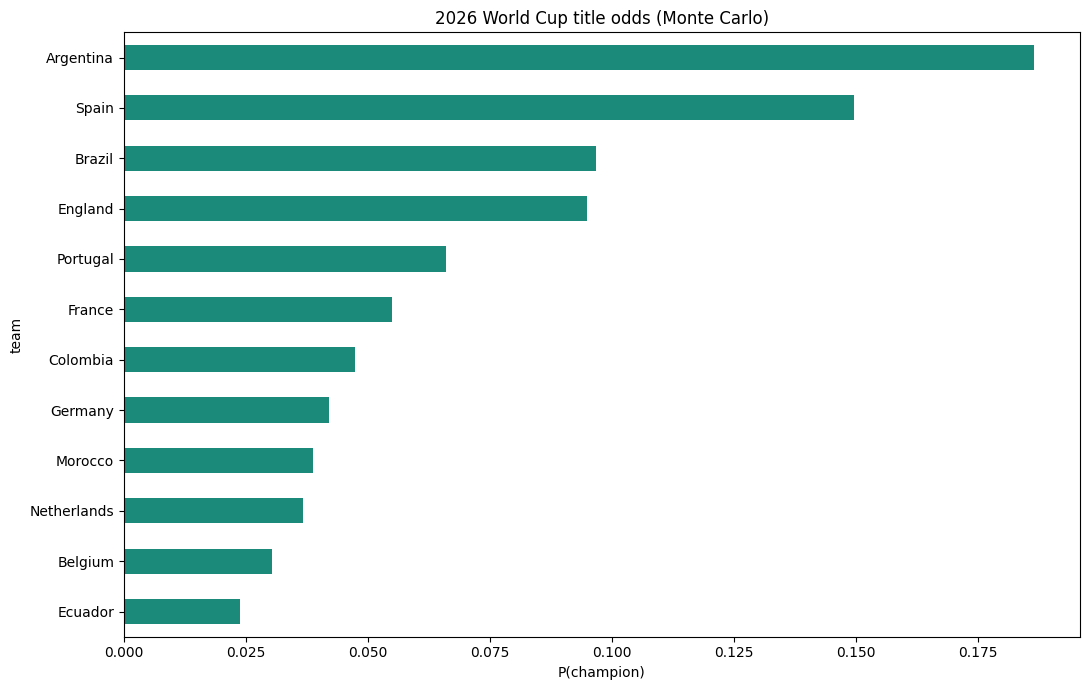

In [16]:
import matplotlib.pyplot as plt
print(T.head(12).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

top = T.head(12).iloc[::-1]
ax = top.plot.barh(x="team", y="Champion", legend=False, figsize=(11,7), color="#1c8a7a")
ax.set_title("2026 World Cup title odds (Monte Carlo)"); ax.set_xlabel("P(champion)")
plt.tight_layout(); plt.show()